<h1>Analization of movies metadata</h1>

<h4>Imports</h4>

In [1]:
from test import get_movies_metadata_df
import numpy as np

import matplotlib.pyplot as plt

movies_metadata = get_movies_metadata_df()

/home/hplinux/Desktop/movies/test.py:14: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(filepath)


<h3>Adult column</h3>

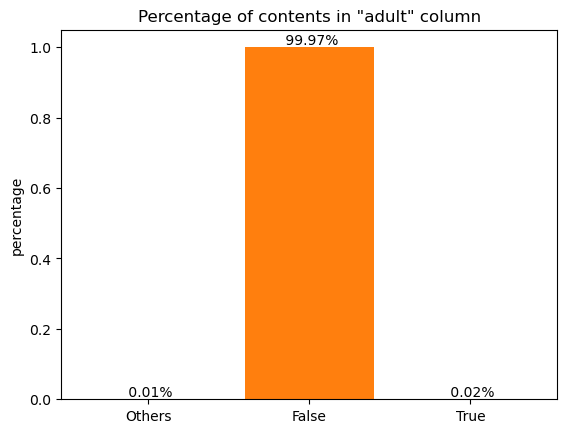

In [2]:
adults = movies_metadata["adult"]

unique, counts = np.unique(adults, return_counts=True)
counts_sum = np.sum(counts)

others = [x for x in unique if x not in ["True", "False"]]
others_counts = np.sum(counts[:3])

unique = ["Others", "False", "True"]
counts = [others_counts, counts[-2], counts[-1]]
counts_percentage = [x / counts_sum for x in counts]

fig, ax = plt.subplots()

ax.bar(unique, counts_percentage)
bar_container = ax.bar(unique, counts_percentage)
ax.set(ylabel='percentage', title='Percentage of contents in "adult" column')
ax.bar_label(bar_container, fmt=lambda x: f"{x * 100: .2f}%")

plt.show()
fig.clf()

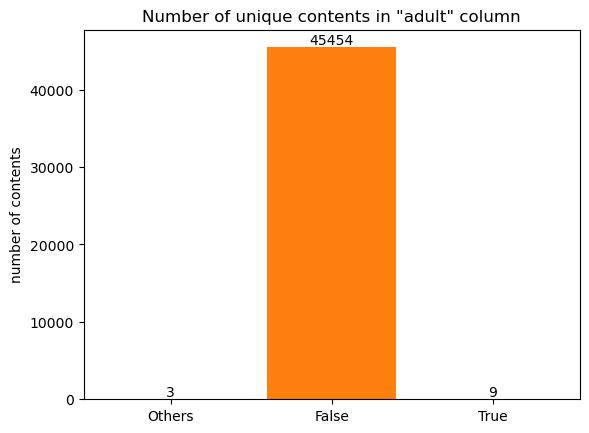

<Figure size 640x480 with 0 Axes>

In [3]:
fig, ax = plt.subplots()

ax.bar(unique, counts_percentage)
bar_container = ax.bar(unique, counts)
ax.set(ylabel='number of contents', title='Number of unique contents in "adult" column')
ax.bar_label(bar_container)

plt.show()
plt.clf()

<h3>Video column</h3>

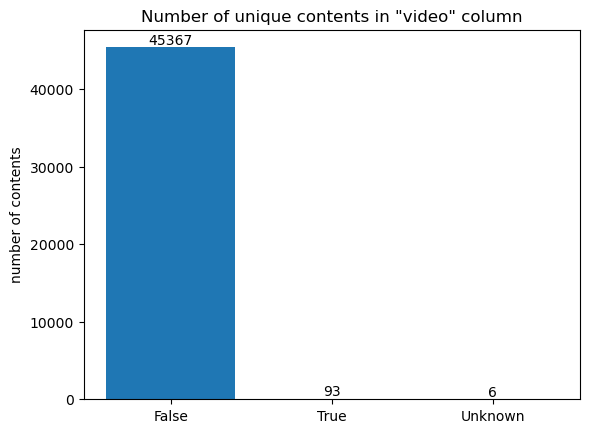

In [4]:
video = movies_metadata["video"]
unique, counts = np.unique(video, return_counts=True)

nan_count = 0
false_count = 0
true_count = 0

for i, val in enumerate(unique):
    if val is True:
        true_count += counts[i]
    elif val is False:
        false_count += counts[i]
    else:
        nan_count += counts[i]

unique = ["False", "True", "Unknown"]
counts = [false_count, true_count, nan_count]
sum_counts = false_count + true_count + nan_count
counts_percentage = [x/sum_counts for x in counts]

fig, ax = plt.subplots()

bar_container = ax.bar(unique, counts)
ax.set(ylabel='number of contents', title='Number of unique contents in "video" column')
ax.bar_label(bar_container)

plt.show()
plt.close(fig)

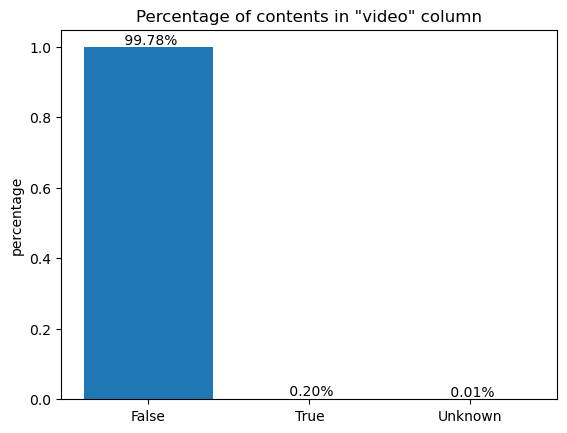

In [5]:
fig, ax = plt.subplots()

bar_container = ax.bar(unique, counts_percentage)
ax.set(ylabel='percentage', title='Percentage of contents in "video" column')
ax.bar_label(bar_container, fmt=lambda x: f"{x * 100: .2f}%")

plt.show()
plt.close(fig)

<h3>"Belongs to collection" column</h3>

In [6]:
collection = movies_metadata["belongs_to_collection"]
print(collection.head(n=10))
print(collection.tail(n=10))

0    {'id': 10194, 'name': 'Toy Story Collection', ...
1                                                  NaN
2    {'id': 119050, 'name': 'Grumpy Old Men Collect...
3                                                  NaN
4    {'id': 96871, 'name': 'Father of the Bride Col...
5                                                  NaN
6                                                  NaN
7                                                  NaN
8                                                  NaN
9    {'id': 645, 'name': 'James Bond Collection', '...
Name: belongs_to_collection, dtype: object
45456    NaN
45457    NaN
45458    NaN
45459    NaN
45460    NaN
45461    NaN
45462    NaN
45463    NaN
45464    NaN
45465    NaN
Name: belongs_to_collection, dtype: object


In [7]:
vals = [type(x) == str for x in collection]
unique, counts = np.unique(vals, return_counts=True)
counts_sum = np.sum(counts)
counts_percentage = [x/counts_sum for x in counts]

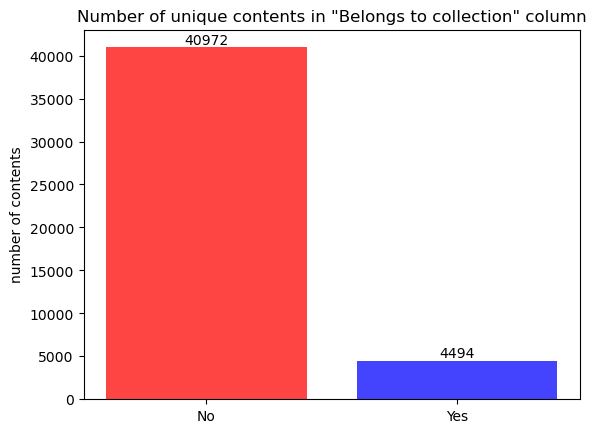

In [8]:
fig, ax = plt.subplots()

bar_colors = ["#ff4444", "#4444ff"]
bar_container = ax.bar(["No", "Yes"], counts, color=bar_colors)
ax.set(ylabel='number of contents', title='Number of unique contents in "Belongs to collection" column')
ax.bar_label(bar_container)
plt.show()
plt.close(fig)

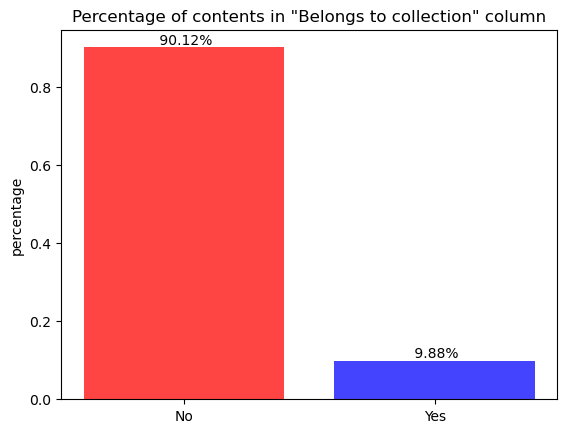

In [9]:
fig, ax = plt.subplots()

bar_colors = ["#ff4444", "#4444ff"]
bar_container = ax.bar(["No", "Yes"], counts_percentage, color=bar_colors)
ax.set(ylabel='percentage', title='Percentage of contents in "Belongs to collection" column')
ax.bar_label(bar_container, fmt=lambda x: f"{x * 100: .2f}%")
plt.show()
plt.close(fig)

<h3>"Homepage" column</h3>

In [10]:
homepages = movies_metadata["homepage"]
print(homepages.head(n=10))
print(homepages.tail(n=10))

0            http://toystory.disney.com/toy-story
1                                             NaN
2                                             NaN
3                                             NaN
4                                             NaN
5                                             NaN
6                                             NaN
7                                             NaN
8                                             NaN
9    http://www.mgm.com/view/movie/757/Goldeneye/
Name: homepage, dtype: object
45456                                     NaN
45457                                     NaN
45458                                     NaN
45459                                     NaN
45460                                     NaN
45461    http://www.imdb.com/title/tt6209470/
45462                                     NaN
45463                                     NaN
45464                                     NaN
45465                                     NaN
Name: home

In [11]:
vals = [type(x) == str for x in homepages]
unique, counts = np.unique(vals, return_counts=True)
counts_sum = np.sum(counts)
counts_percentage = [x/counts_sum for x in counts]

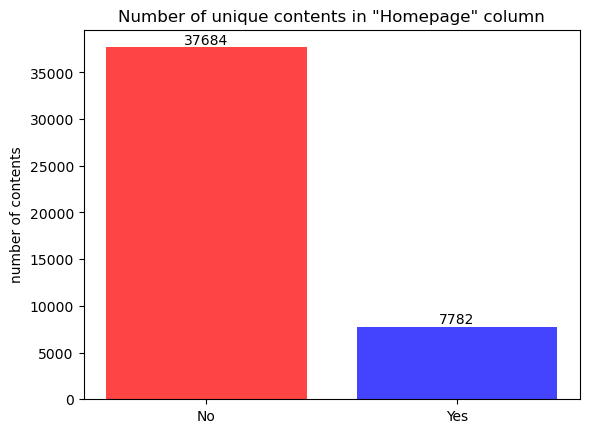

In [12]:
fig, ax = plt.subplots()
bar_colors = ["#ff4444", "#4444ff"]
bar_container = ax.bar(["No", "Yes"], counts, color=bar_colors)
ax.set(ylabel='number of contents', title='Number of unique contents in "Homepage" column')
ax.bar_label(bar_container)
plt.show()
plt.close(fig)

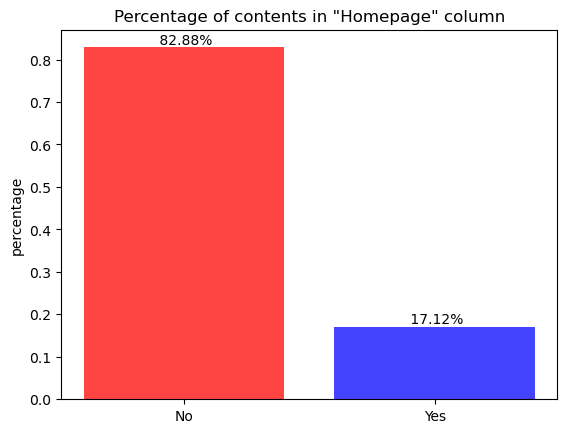

In [13]:
fig, ax = plt.subplots()
bar_colors = ["#ff4444", "#4444ff"]
bar_container = ax.bar(["No", "Yes"], counts_percentage, color=bar_colors)
ax.set(ylabel='percentage', title='Percentage of contents in "Homepage" column')
ax.bar_label(bar_container, fmt=lambda x: f"{x * 100: .2f}%")
plt.show()
plt.close(fig)